# Étape 4 : Modélisation Machine Learning - PySpark

## Objectif
Construire et évaluer différents modèles de Machine Learning pour **prédire le trafic vélo** en fonction des conditions météo et temporelles **en utilisant PySpark MLlib**.

## Plan
1. Charger le dataset final (format Parquet)
2. Préparer les features avec VectorAssembler
3. Diviser les données en train/test (80/20)
4. Entraîner plusieurs modèles de régression :
   - Régression Linéaire
   - Decision Tree
   - Random Forest
   - Gradient Boosted Trees
5. Évaluer les performances (RMSE, MAE, R²)
6. Comparer les modèles
7. Analyser les features les plus importantes
8. Sauvegarder le meilleur modèle

---

## 4.1 Initialisation et Chargement des Données

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Créer Spark Session
spark = SparkSession.builder \
    .appName("MeteoVelo - Modélisation ML") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Spark Session créée!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/19 15:01:47 WARN Utils: Your hostname, Stan, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/19 15:01:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/19 15:01:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark Session créée!


In [4]:
# Charger le dataset final en format Parquet (conserve les types et vecteurs)
print("📂 Chargement du dataset final...\n")

df = spark.read.parquet('../data/data_final_spark.parquet')

print(f"✅ Dataset chargé : {df.count():,} lignes x {len(df.columns)} colonnes")
print("\n" + "="*80)
print("Schema du dataset :")
df.printSchema()

print("\n" + "="*80)
print("Aperçu des données :")
df.show(5, truncate=False)

📂 Chargement du dataset final...

✅ Dataset chargé : 696 lignes x 14 colonnes

Schema du dataset :
root
 |-- timestamp: timestamp (nullable = true)
 |-- nb_velos: integer (nullable = true)
 |-- temperature: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- is_raining: integer (nullable = true)
 |-- rain_intensity: string (nullable = true)
 |-- temp_category: string (nullable = true)
 |-- rain_intensity_encoded: vector (nullable = true)
 |-- temp_category_encoded: vector (nullable = true)


Aperçu des données :
+-------------------+--------+------------------+-------------------+----+-----------+----------+------------+-----+----------+--------------+-------------+----------------------+---------------------+
|timestamp          |nb_velos|temperature       |p

---
## 4.2 Préparation des Features

### VectorAssembler
Les modèles PySpark MLlib nécessitent que toutes les features soient regroupées dans **une seule colonne de type Vector**.

**VectorAssembler** combine plusieurs colonnes en un seul vecteur de features.

### Features sélectionnées :
- **Numériques** : temperature, precipitation, hour, day_of_week, is_weekend, is_rush_hour, month, is_raining
- **Encodées** : rain_intensity_encoded, temp_category_encoded

### Variable cible :
- `nb_velos` (nombre de vélos)

In [5]:
print("🔧 Préparation des features avec VectorAssembler...\n")

# Features numériques
numeric_features = [
    'temperature',
    'precipitation', 
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'month',
    'is_raining'
]

# Features encodées (vecteurs)
encoded_features = [
    'rain_intensity_encoded',
    'temp_category_encoded'
]

# Assembler toutes les features en un seul vecteur
assembler = VectorAssembler(
    inputCols=numeric_features + encoded_features,
    outputCol='features'
)

# Transformer le dataset
df_features = assembler.transform(df)

# Sélectionner uniquement les colonnes nécessaires pour le ML
df_ml = df_features.select('features', 'nb_velos')

# Renommer nb_velos en 'label' (convention PySpark ML)
df_ml = df_ml.withColumnRenamed('nb_velos', 'label')

print("✅ Features assemblées!")
print(f"\nNombre de features : {len(numeric_features) + 2} (8 numériques + 2 vecteurs encodés)")
print(f"Variable cible : label (nb_velos)")

print("\n" + "="*80)
print("Aperçu du dataset ML :")
df_ml.show(5, truncate=True)

🔧 Préparation des features avec VectorAssembler...

✅ Features assemblées!

Nombre de features : 10 (8 numériques + 2 vecteurs encodés)
Variable cible : label (nb_velos)

Aperçu du dataset ML :
+--------------------+-----+
|            features|label|
+--------------------+-----+
|(17,[0,1,3,6,7,9,...| 3607|
|(17,[0,2,3,6,8,15...| 1762|
|(17,[0,1,2,3,6,7,...| 1207|
|(17,[0,1,2,3,6,7,...|  878|
|(17,[0,1,2,3,6,7,...|  652|
+--------------------+-----+
only showing top 5 rows


---
## 4.3 Division Train / Test

### Stratégie :
- **80% Train** : Pour entraîner les modèles
- **20% Test** : Pour évaluer les performances sur des données non vues
- `seed=42` : Pour la reproductibilité

In [6]:
print("✂️ Division des données Train / Test...\n")

# Split 80/20 avec seed pour reproductibilité
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

# Cache pour accélérer les calculs répétés
train_data.cache()
test_data.cache()

print(f"📊 Dataset Train : {train_data.count():,} lignes")
print(f"📊 Dataset Test  : {test_data.count():,} lignes")
print(f"\n✅ Ratio : {train_data.count() / df_ml.count() * 100:.1f}% / {test_data.count() / df_ml.count() * 100:.1f}%")

✂️ Division des données Train / Test...

📊 Dataset Train : 585 lignes
📊 Dataset Test  : 111 lignes

✅ Ratio : 84.1% / 15.9%


---
## 4.4 Entraînement des Modèles

### Modèles à tester :

1. **Régression Linéaire**
   - Modèle simple, rapide
   - Suppose une relation linéaire entre features et cible

2. **Decision Tree**
   - Arbre de décision
   - Capture les relations non-linéaires
   - Risque de surapprentissage

3. **Random Forest**
   - Ensemble de Decision Trees
   - Plus robuste, moins de surapprentissage
   - Peut identifier les features importantes

4. **Gradient Boosted Trees (GBT)**
   - Boosting : arbres séquentiels qui corrigent les erreurs
   - Souvent les meilleures performances
   - Plus lent à entraîner

### 4.4.1 Régression Linéaire

In [7]:
print("📈 Entraînement Régression Linéaire...\n")

# Créer le modèle
lr = LinearRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=100,
    regParam=0.1,  # Régularisation L2
    elasticNetParam=0.0  # 0=L2, 1=L1
)

# Entraîner
lr_model = lr.fit(train_data)

# Prédire sur le test
lr_predictions = lr_model.transform(test_data)

print("✅ Régression Linéaire entraînée!")
print(f"Coefficients : {len(lr_model.coefficients)} features")
print(f"Intercept : {lr_model.intercept:.2f}")

📈 Entraînement Régression Linéaire...



25/12/19 15:02:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/19 15:02:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


✅ Régression Linéaire entraînée!
Coefficients : 17 features
Intercept : -1416.08


### 4.4.2 Decision Tree

In [8]:
print("🌳 Entraînement Decision Tree...\n")

# Créer le modèle
dt = DecisionTreeRegressor(
    featuresCol='features',
    labelCol='label',
    maxDepth=10,
    minInstancesPerNode=5,
    seed=42
)

# Entraîner
dt_model = dt.fit(train_data)

# Prédire
dt_predictions = dt_model.transform(test_data)

print("✅ Decision Tree entraîné!")
print(f"Profondeur de l'arbre : {dt_model.depth}")
print(f"Nombre de noeuds : {dt_model.numNodes}")

🌳 Entraînement Decision Tree...

✅ Decision Tree entraîné!
Profondeur de l'arbre : 10
Nombre de noeuds : 173


### 4.4.3 Random Forest

In [9]:
print("🌲 Entraînement Random Forest...\n")

# Créer le modèle
rf = RandomForestRegressor(
    featuresCol='features',
    labelCol='label',
    numTrees=100,  # Nombre d'arbres dans la forêt
    maxDepth=10,
    minInstancesPerNode=5,
    seed=42
)

# Entraîner
rf_model = rf.fit(train_data)

# Prédire
rf_predictions = rf_model.transform(test_data)

print("✅ Random Forest entraîné!")
print(f"Nombre d'arbres : {rf_model.getNumTrees}")
print(f"Profondeur moyenne : {sum([tree.depth for tree in rf_model.trees]) / len(rf_model.trees):.1f}")

🌲 Entraînement Random Forest...



25/12/19 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 1123.4 KiB
25/12/19 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 1439.6 KiB
25/12/19 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 1702.1 KiB
25/12/19 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 1900.8 KiB


✅ Random Forest entraîné!
Nombre d'arbres : 100
Profondeur moyenne : 10.0


### 4.4.4 Gradient Boosted Trees

In [10]:
print("🚀 Entraînement Gradient Boosted Trees...\n")

# Créer le modèle
gbt = GBTRegressor(
    featuresCol='features',
    labelCol='label',
    maxIter=100,  # Nombre d'itérations de boosting
    maxDepth=5,
    stepSize=0.1,  # Learning rate
    seed=42
)

# Entraîner
gbt_model = gbt.fit(train_data)

# Prédire
gbt_predictions = gbt_model.transform(test_data)

print("✅ Gradient Boosted Trees entraîné!")
print(f"Nombre d'arbres : {gbt_model.getNumTrees}")

🚀 Entraînement Gradient Boosted Trees...

✅ Gradient Boosted Trees entraîné!
Nombre d'arbres : 100


---
## 4.5 Évaluation des Modèles

### Métriques d'évaluation :

1. **RMSE (Root Mean Squared Error)**
   - Erreur quadratique moyenne
   - Pénalise plus les grandes erreurs
   - Même unité que la cible (nombre de vélos)
   - **Plus bas = mieux**

2. **MAE (Mean Absolute Error)**
   - Erreur absolue moyenne
   - Moins sensible aux outliers
   - **Plus bas = mieux**

3. **R² (Coefficient de détermination)**
   - Proportion de variance expliquée
   - Entre 0 et 1 (peut être négatif si très mauvais)
   - **Plus haut = mieux** (1 = prédiction parfaite)

In [11]:
print("📊 Évaluation des performances...\n")

# Créer les évaluateurs
evaluator_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
evaluator_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae')
evaluator_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2')

# Fonction pour évaluer un modèle
def evaluate_model(predictions, model_name):
    rmse = evaluator_rmse.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    return {
        'Modèle': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

# Évaluer tous les modèles
results = []
results.append(evaluate_model(lr_predictions, 'Régression Linéaire'))
results.append(evaluate_model(dt_predictions, 'Decision Tree'))
results.append(evaluate_model(rf_predictions, 'Random Forest'))
results.append(evaluate_model(gbt_predictions, 'Gradient Boosted Trees'))

# Créer un DataFrame Pandas pour affichage
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')  # Trier par RMSE (meilleur en premier)

print("="*80)
print("📊 RÉSULTATS DES MODÈLES (sur données de test)")
print("="*80)
print(results_df.to_string(index=False))
print("\n💡 Le meilleur modèle a le RMSE le plus bas et le R² le plus haut")

📊 Évaluation des performances...

📊 RÉSULTATS DES MODÈLES (sur données de test)
                Modèle        RMSE         MAE       R²
Gradient Boosted Trees 2039.591892 1178.988812 0.948574
         Decision Tree 2355.707635 1597.143440 0.931397
         Random Forest 3044.012955 1983.639433 0.885451
   Régression Linéaire 5358.924534 3958.883992 0.644980

💡 Le meilleur modèle a le RMSE le plus bas et le R² le plus haut


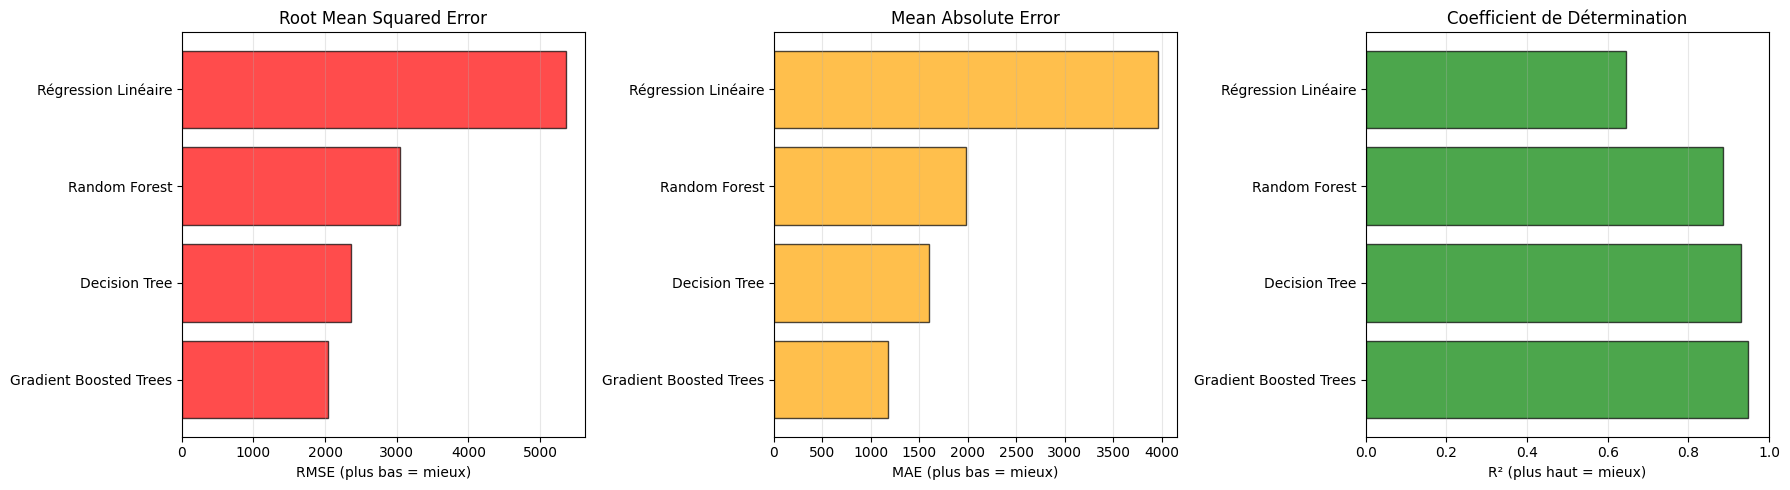


🏆 Meilleur modèle : Gradient Boosted Trees
   RMSE : 2039.59 vélos
   MAE  : 1178.99 vélos
   R²   : 0.949


In [12]:
# Visualisation comparative des modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE
axes[0].barh(results_df['Modèle'], results_df['RMSE'], color='red', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('RMSE (plus bas = mieux)')
axes[0].set_title('Root Mean Squared Error')
axes[0].grid(True, alpha=0.3, axis='x')

# MAE
axes[1].barh(results_df['Modèle'], results_df['MAE'], color='orange', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('MAE (plus bas = mieux)')
axes[1].set_title('Mean Absolute Error')
axes[1].grid(True, alpha=0.3, axis='x')

# R²
axes[2].barh(results_df['Modèle'], results_df['R²'], color='green', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('R² (plus haut = mieux)')
axes[2].set_title('Coefficient de Détermination')
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\n🏆 Meilleur modèle : {results_df.iloc[0]['Modèle']}")
print(f"   RMSE : {results_df.iloc[0]['RMSE']:.2f} vélos")
print(f"   MAE  : {results_df.iloc[0]['MAE']:.2f} vélos")
print(f"   R²   : {results_df.iloc[0]['R²']:.3f}")

---
## 4.6 Analyse des Prédictions

Visualiser les prédictions vs les valeurs réelles pour le meilleur modèle.

📊 Visualisation des prédictions - Gradient Boosted Trees



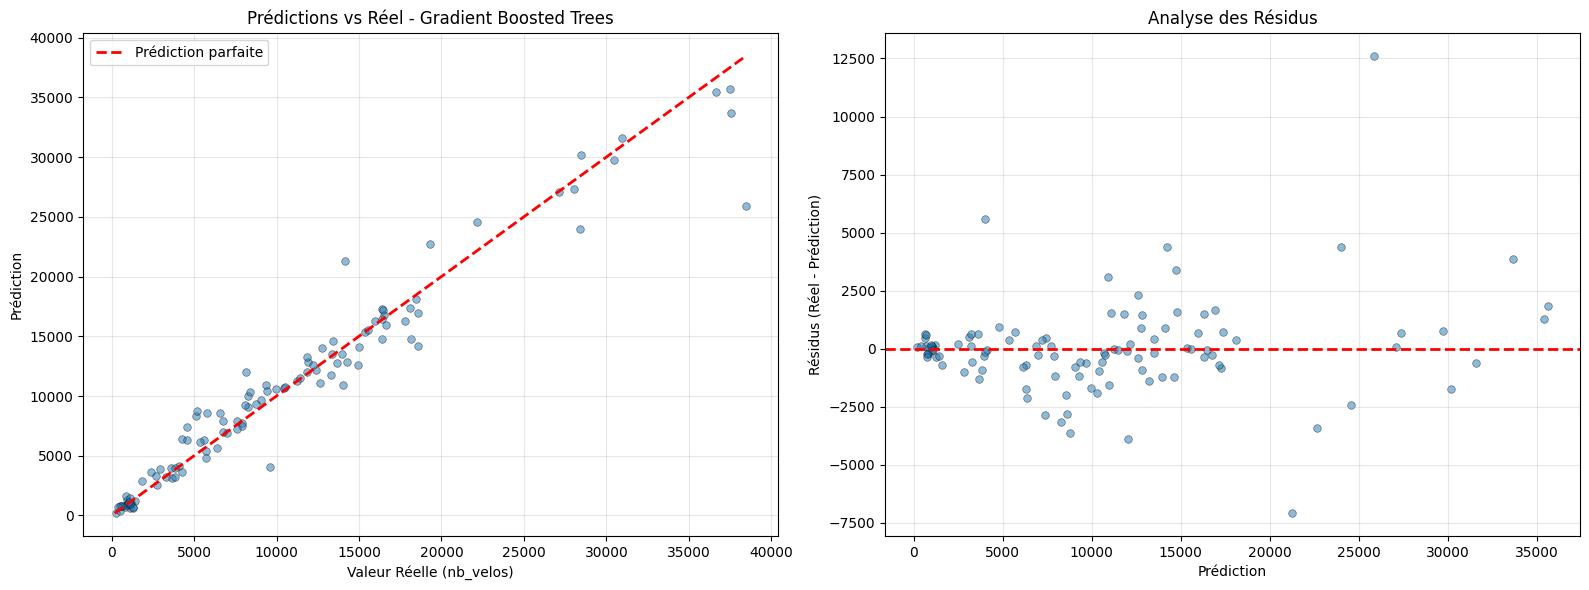


💡 Interprétation :
- Si les points sont proches de la ligne rouge → bonnes prédictions
- Si les résidus sont proches de 0 → le modèle ne sous/sur-estime pas systématiquement


In [13]:
# Identifier le meilleur modèle
best_model_name = results_df.iloc[0]['Modèle']

# Récupérer les prédictions du meilleur modèle
if best_model_name == 'Régression Linéaire':
    best_predictions = lr_predictions
elif best_model_name == 'Decision Tree':
    best_predictions = dt_predictions
elif best_model_name == 'Random Forest':
    best_predictions = rf_predictions
else:  # GBT
    best_predictions = gbt_predictions

# Convertir en Pandas pour visualisation
predictions_df = best_predictions.select('label', 'prediction').toPandas()

print(f"📊 Visualisation des prédictions - {best_model_name}\n")

# Graphique 1 : Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prédictions vs Réel
axes[0].scatter(predictions_df['label'], predictions_df['prediction'], 
                alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
# Ligne de référence parfaite (y=x)
min_val = min(predictions_df['label'].min(), predictions_df['prediction'].min())
max_val = max(predictions_df['label'].max(), predictions_df['prediction'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeur Réelle (nb_velos)')
axes[0].set_ylabel('Prédiction')
axes[0].set_title(f'Prédictions vs Réel - {best_model_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Résidus (erreurs)
residuals = predictions_df['label'] - predictions_df['prediction']
axes[1].scatter(predictions_df['prediction'], residuals, 
                alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Résidus (Réel - Prédiction)')
axes[1].set_title('Analyse des Résidus')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print("- Si les points sont proches de la ligne rouge → bonnes prédictions")
print("- Si les résidus sont proches de 0 → le modèle ne sous/sur-estime pas systématiquement")

---
## 4.7 Feature Importance (Random Forest)

Identifier quelles features ont le plus d'impact sur les prédictions.

📊 Feature Importance - Gradient Boosted Trees

      Feature  Importance
         hour    0.340965
 is_rush_hour    0.259902
  day_of_week    0.187931
  temperature    0.138067
precipitation    0.021935
   rain_light    0.019883
    temp_cold    0.012441
    temp_cool    0.006414
   is_weekend    0.005483
    temp_mild    0.003130
    temp_warm    0.001524
 rain_no_rain    0.001513
     temp_hot    0.000391
   is_raining    0.000230
rain_moderate    0.000187
   rain_heavy    0.000003
        month    0.000000


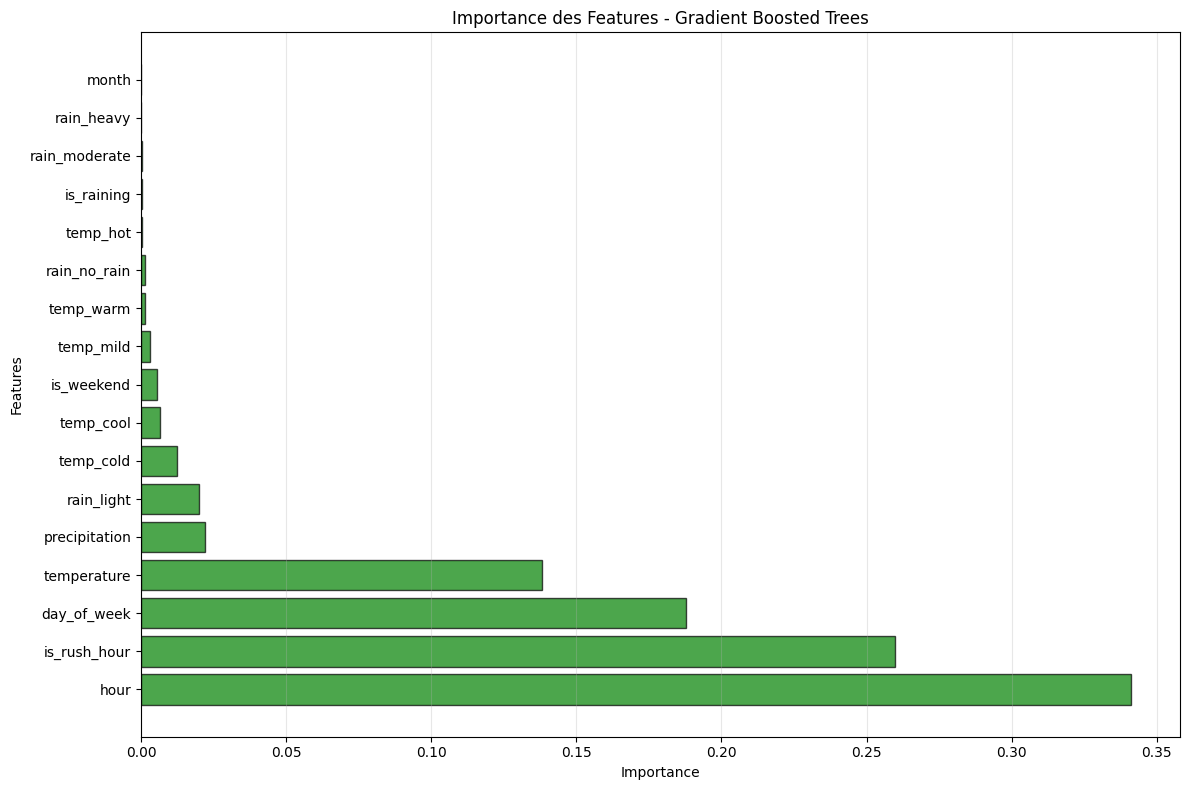


💡 Les features en haut sont les plus importantes pour prédire le trafic vélo


In [16]:
# Feature importance disponible pour Random Forest et GBT
if best_model_name in ['Random Forest', 'Gradient Boosted Trees']:
    print(f"📊 Feature Importance - {best_model_name}\n")

    # Récupérer le modèle
    model = rf_model if best_model_name == 'Random Forest' else gbt_model

      # Feature importances
    importances = model.featureImportances.toArray()

    # Noms des features (dans l'ordre du VectorAssembler)
      # Les vecteurs encodés créent plusieurs colonnes
      # rain_intensity_encoded: no_rain, light, moderate, heavy (4 colonnes)
      # temp_category_encoded: cold, cool, mild, warm, hot (5 colonnes)
    feature_names = numeric_features + \
                    ['rain_no_rain', 'rain_light', 'rain_moderate', 'rain_heavy'] + \
                    ['temp_cold', 'temp_cool', 'temp_mild', 'temp_warm', 'temp_hot']

      # Vérifier que le nombre de features correspond
    if len(feature_names) != len(importances):
        print(f"⚠️ Attention : {len(feature_names)} noms vs {len(importances)} importances")
          # Créer des noms génériques si mismatch
        feature_names = [f'feature_{i}' for i in range(len(importances))]

      # Créer un DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print("="*80)
    print(importance_df.to_string(index=False))
    print("="*80)

      # Visualisation
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'],
            color='green', alpha=0.7, edgecolor='black')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.title(f'Importance des Features - {best_model_name}')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    print("\n💡 Les features en haut sont les plus importantes pour prédire le trafic vélo")
else:
    print(f"⚠️ Feature importance non disponible pour {best_model_name}")

---
## 4.8 Sauvegarde du Meilleur Modèle

In [17]:
# Sauvegarder le meilleur modèle
model_path = '../models/best_model_spark'

# Récupérer le meilleur modèle
if best_model_name == 'Régression Linéaire':
    best_model = lr_model
elif best_model_name == 'Decision Tree':
    best_model = dt_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = gbt_model

# Sauvegarder
best_model.write().overwrite().save(model_path)

print(f"💾 Modèle sauvegardé : {model_path}")
print(f"🏆 Modèle : {best_model_name}")
print(f"📊 Performances :")
print(f"   - RMSE : {results_df.iloc[0]['RMSE']:.2f} vélos")
print(f"   - MAE  : {results_df.iloc[0]['MAE']:.2f} vélos")
print(f"   - R²   : {results_df.iloc[0]['R²']:.3f}")

print("\n✅ Le modèle peut être rechargé avec :")
if best_model_name == 'Random Forest':
    print(f"   from pyspark.ml.regression import RandomForestRegressionModel")
    print(f"   model = RandomForestRegressionModel.load('{model_path}')")
elif best_model_name == 'Gradient Boosted Trees':
    print(f"   from pyspark.ml.regression import GBTRegressionModel")
    print(f"   model = GBTRegressionModel.load('{model_path}')")
elif best_model_name == 'Decision Tree':
    print(f"   from pyspark.ml.regression import DecisionTreeRegressionModel")
    print(f"   model = DecisionTreeRegressionModel.load('{model_path}')")
else:
    print(f"   from pyspark.ml.regression import LinearRegressionModel")
    print(f"   model = LinearRegressionModel.load('{model_path}')")

💾 Modèle sauvegardé : ../models/best_model_spark
🏆 Modèle : Gradient Boosted Trees
📊 Performances :
   - RMSE : 2039.59 vélos
   - MAE  : 1178.99 vélos
   - R²   : 0.949

✅ Le modèle peut être rechargé avec :
   from pyspark.ml.regression import GBTRegressionModel
   model = GBTRegressionModel.load('../models/best_model_spark')


---
## 4.9 Résumé de l'Étape 4

### ✅ Ce qui a été fait :

1. **Préparation des données**
   - Chargement du dataset final (Parquet)
   - Assemblage des features avec VectorAssembler
   - Split Train/Test (80/20)

2. **Modèles entraînés**
   - ✅ Régression Linéaire
   - ✅ Decision Tree
   - ✅ Random Forest
   - ✅ Gradient Boosted Trees

3. **Évaluation**
   - Métriques : RMSE, MAE, R²
   - Comparaison des performances
   - Analyse des prédictions et résidus

4. **Feature Importance**
   - Identification des features les plus impactantes
   - Visualisation

5. **Sauvegarde**
   - Meilleur modèle sauvegardé
   - Prêt pour déploiement/utilisation

### 📊 Résultats :
Voir le tableau de comparaison ci-dessus pour les performances exactes de chaque modèle.

### 🎯 Prochaines Étapes Possibles :
1. **Optimisation des hyperparamètres** (GridSearch, CrossValidation)
2. **Feature Engineering avancé** (interactions, polynômes)
3. **Déploiement du modèle** (API, batch predictions)
4. **Monitoring** (retraining, drift detection)

---
**✅ Étape 4 terminée ! Le projet Machine Learning est complet !**

In [18]:
# Nettoyage
train_data.unpersist()
test_data.unpersist()

# Arrêter la Spark Session
spark.stop()
print("✅ Spark Session arrêtée!")

✅ Spark Session arrêtée!
